In [4]:
%load_ext autoreload
%autoreload 2

In [5]:
from codes.PNGmodel import PNGmodel
from codes.corner_plots import make_corner
from codes.chain import chain

# Initialize and load all parts of the model

In [2]:
mod = PNGmodel(fid_corr = './inputs/abacus_averaged_fiducial_wts_fixed.fits', 
               cov_pkg = './inputs/EZ_mock_covariance_matrix.npy', 
               exclude=['xi2','xi4'],
               s_max=380, s_cutwindow = [90, 130])

mod.load_PNG_model(png_quadfits_files = ['./inputs/quadfits_LRG_FastPM_Y3_fnl_xi0.csv',
                                         './inputs/quadfits_LRG_FastPM_Y3_fnl_xi2.csv',
                                         './inputs/quadfits_LRG_FastPM_Y3_fnl_xi4.csv'])

mod.load_covariance()

mod.load_photo_vary_fits(pkg_set1 = ['./inputs/quadfits_LRG_abacus_Y1_Ksys_SGC_xi0.csv',
                                     './inputs/quadfits_LRG_abacus_Y1_Ksys_SGC_xi2.csv',
                                     './inputs/quadfits_LRG_abacus_Y1_Ksys_SGC_xi4.csv'],
                         pkg_set2 = ['./inputs/quadfits_LRG_abacus_Y1_Ksys_DEC_xi0.csv',
                                     './inputs/quadfits_LRG_abacus_Y1_Ksys_DEC_xi2.csv',
                                     './inputs/quadfits_LRG_abacus_Y1_Ksys_DEC_xi4.csv'],
                         pkg_set3 = ['./inputs/quadfits_LRG_abacus_Y1_Ksys_MZLS_xi0.csv',
                                     './inputs/quadfits_LRG_abacus_Y1_Ksys_MZLS_xi2.csv',
                                     './inputs/quadfits_LRG_abacus_Y1_Ksys_MZLS_xi4.csv'])

Initializing...
Observable will have 31 pts
Loading PNG model...
Loading covariance matrix...
Loading systematic weight variation...


# Run MCMC 

Exploring paramter space...


100%|██████████| 20000/20000 [02:46<00:00, 120.20it/s]


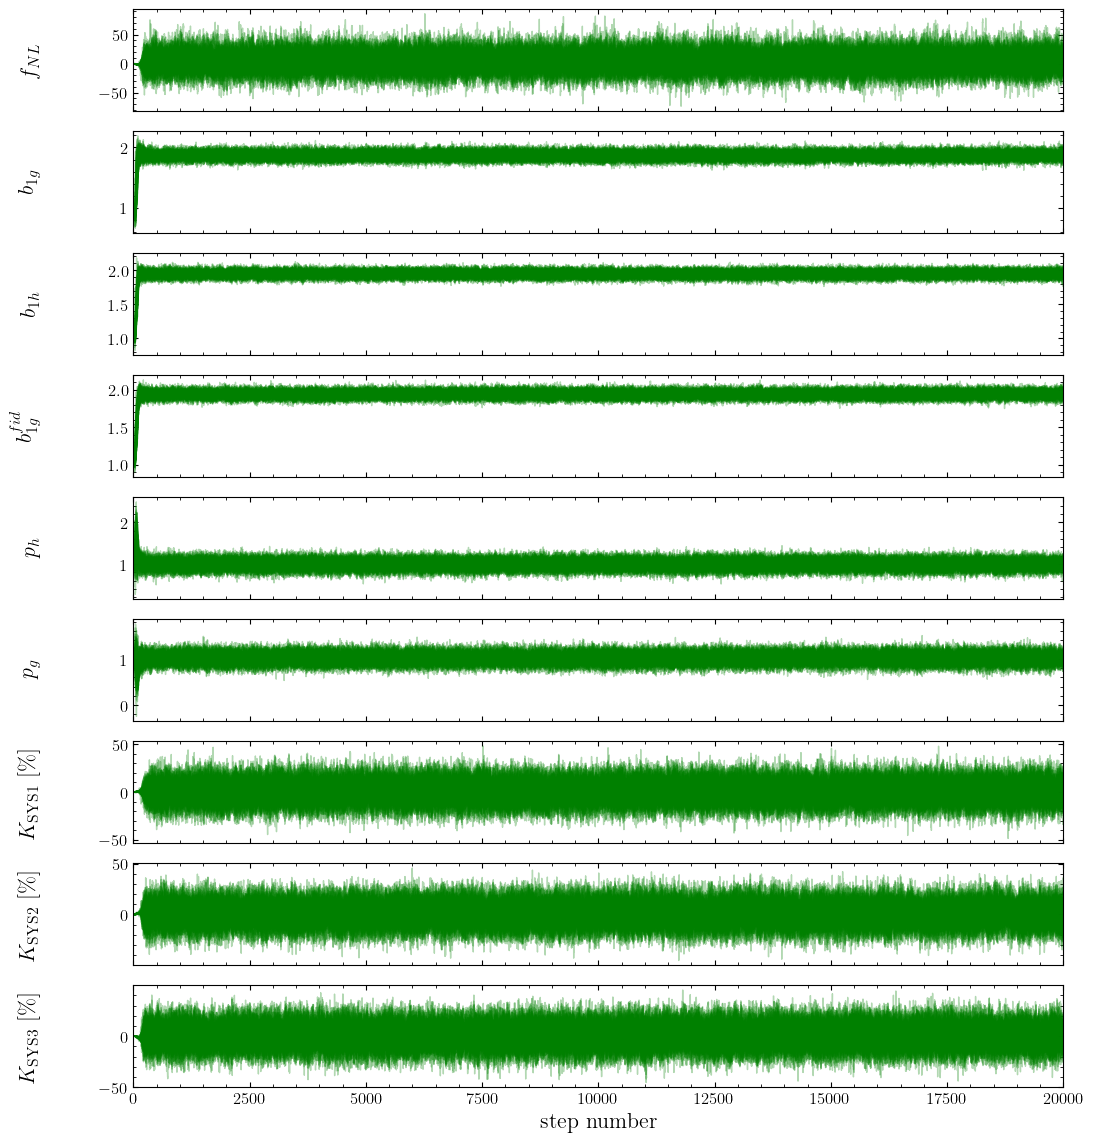

In [ ]:
mod.test_model_base_pars(min_type = 'data',
                         poi_hard_lims = ((-250,250),(0.5,4)), 
                         gauss_priors = ((1.94,0.04),(1.94,0.04),(1,0.1),(1,0.1)),
                         Psys1_gauss_prior = (0,10),
                         Psys2_gauss_prior = (0,10),
                         Psys3_gauss_prior = (0,10),
                         z_eff = 0.780, # v1.5 0.780, nbody png 0.787
                         Om_m0_g = 0.315,
                         z_fid = 0.776,
                         zhalo = 0.787, # box 0.819, y3 0.787
                         Om_m0_h = 0.3089, #
                         nwalkers = 75, #50
                         nsteps = 2000, # Should default to 20000, set to 2000 for code testing
                         plt_color = 'green',
                         fname = None, 
                         # poi_toy = (0,1.8), nuiss_toy = (1.8, 1.8, 1, 1), Psys1_toy = 0, Psys2_toy = 0, Psys3_toy = 0,
                         data_obs = f'./inputs/Y1_LRG_correlations_v1.5_.fits',
                         plt_out = True)

# Save output

In [4]:
mod.wrap_chain_base_pars(burn_in_steps = 500, thinner = 1,
                         fname_chain = f'./outputs/testchain.txt')

fNL = 4.67 + 14.01 - 14.26
b1g = 1.87 + 0.05 - 0.05
b1h = 1.94 + 0.04 - 0.04
b1gfid = 1.94 + 0.04 - 0.04
pg = 0.99 + 0.1 - 0.1
ph = 1.01 + 0.1 - 0.1
Ksys1 = 0.49 + 9.91 - 9.93
Ksys2 = 0.75 + 9.68 - 9.65
Ksys3 = 0.59 + 9.91 - 9.86


# Make plots

In [8]:
testchain = chain('./outputs/testchain.txt', label='test')

finished loading "test"


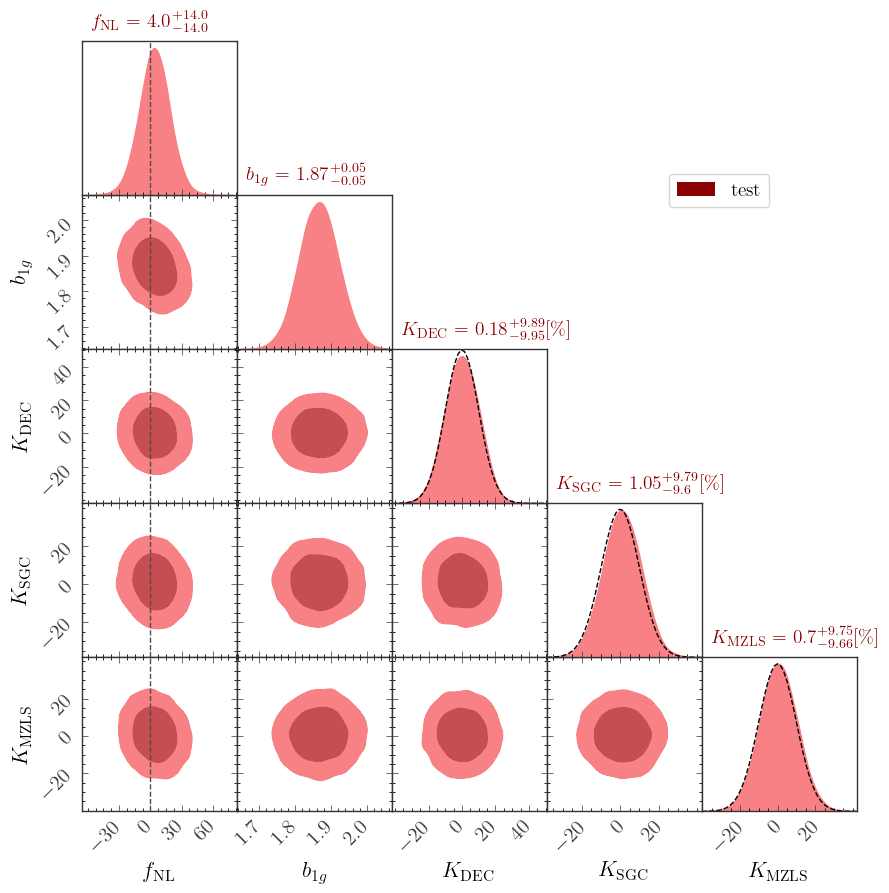

In [11]:
make_corner([testchain])